# African Graduate Launch Benchmark

**Mission:** Help young Africans enter technology careers through teaching, bootcamps,
practical training, mentorship, internships, and employer partnerships.
**Problem:** Program teams need evidence about which learning and first-job pathways are
associated with stronger early-career outcomes.
**Model use:** Estimate a historical first monthly income benchmark for a graduate pathway.
**Decision:** Compare pathways and improve program design; never rank a person's worth.

This is a specific graduate-transition regression task, not a generic salary
or house-price model.

## Dataset and target

The source is the **Stutern Nigerian Graduate Report 2018**, a real survey of 5,219
Nigerian graduates from the 2013–2017 cohorts. Stutern created it to improve African
graduate employment and employer matching. It covers education, skills, internships,
employment status, first jobs, sectors, qualification relevance, and income.

- Source: https://www.kaggle.com/datasets/stutern/nigerian-gradaute-report-2018
- Survey rows: 5,219 with 36 original variables
- Labelled first-employment rows after preparation: 1,656
- Continuous target: midpoint of the reported first monthly income range in Nigerian naira

The source is Nigeria-specific. It provides valuable African evidence, but the results
must not be presented as representative of every African country.

In [1]:
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

from API.config import MODEL_FEATURES, NUMERIC_FEATURES, TARGET
from API.training import (
    RANDOM_STATE, build_sgd_loss_curve, calculate_metrics, make_pipeline,
    model_definitions, tune_sgd,
)

sns.set_theme(style="whitegrid", palette="crest")
DATA_PATH = Path("data/africa_graduate_first_income.csv")
data = pd.read_csv(DATA_PATH)
print(f"Prepared shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
tech_rows = (data["first_job_sector"] == "Technology and telecommunications").sum()
print(f"Technology and telecommunications pathways: {tech_rows:,}")
data.head()

Prepared shape: 1,656 rows × 13 columns
Technology and telecommunications pathways: 277


,graduation_year,education_level,course_group,first_job_level,first_job_sector,qualification_requirement,first_job_via_nysc,employer_valued_factor,course_preparation_score,employability_skill_count,problem_solving_skill,communication_skill,first_monthly_income_ngn
0,2013,Bachelor's degree,Engineering and built environment,Experienced/professional,Technology and telecommunications,Not required,Not completed,No single factor,1,4,True,True,75000.0
1,2014,Bachelor's degree,Social sciences,Entry level,"Media, marketing and creative",Formal requirement,No,Internship or practical experience,1,4,True,True,35000.0
2,2013,Bachelor's degree,Business and economics,Entry level,Finance and consulting,Formal requirement,No,Subject studied,2,2,False,True,125000.0
3,2013,Bachelor's degree,Technology and computing,Managerial,Other,Gave an advantage,No,Internship or practical experience,3,1,False,False,75000.0
4,2015,Bachelor's degree,Engineering and built environment,Entry level,"Media, marketing and creative",Not required,No,Other,3,2,False,False,35000.0


## Feature engineering and interpretation

The source income is categorical ranges. Each range is converted to its midpoint:
`Under ₦20,000 → ₦10,000`, `₦20,000–₦49,999 → ₦35,000`, through to a documented
`₦275,000` assumption for the open-ended `₦250,000 and more` band.

The following decisions make the model useful and safer:

- timestamp, institution name, employer name, transport, free-text role, and survey
  commentary are dropped because they are identifiers, high-cardinality text, or unrelated;
- gender is deliberately excluded from prediction because it is sensitive and not an
  intervention a youth program should optimize;
- 114 course names become nine teachable course families;
- 30 sectors become nine pathway groups, including technology and telecommunications;
- multi-select skills become a numeric count plus problem-solving and communication flags;
- course-preparation responses become an ordinal 1–4 score;
- detailed qualification and employer responses become stable categories.

Numeric fields are median-imputed and standardized with `StandardScaler`. Categorical
fields are most-frequent-imputed and one-hot encoded. All transformations are fitted only
on training data inside each pipeline, preventing leakage.

In [2]:
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique": data.nunique(),
})
print(f"Duplicate prepared rows: {data.duplicated().sum():,}")
quality

Duplicate prepared rows: 30


,dtype,missing,unique
graduation_year,int64,0,5
education_level,object,0,6
course_group,object,0,9
first_job_level,object,0,5
first_job_sector,object,0,9
qualification_requirement,object,0,4
first_job_via_nysc,object,0,3
employer_valued_factor,object,0,7
course_preparation_score,int64,0,4
employability_skill_count,int64,0,7


## Visualization 1: target distribution

Most reported first incomes are in the lower bands, with a long upper tail. This imbalance
means a median baseline is strong on MAE, while RMSE heavily penalizes mistakes on the
smaller high-income groups. Stratifying the split by target band preserves this structure.

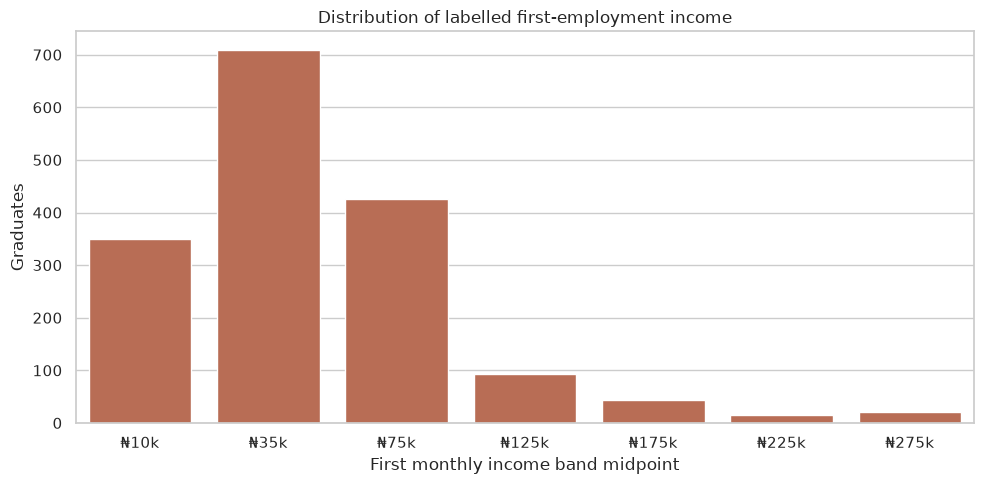

In [3]:
plt.figure(figsize=(10, 5))
order = sorted(data[TARGET].unique())
sns.countplot(data=data, x=TARGET, order=order, color="#c86545")
plt.xticks(
    range(len(order)),
    [f"₦{value/1000:.0f}k" for value in order],
)
plt.xlabel("First monthly income band midpoint")
plt.ylabel("Graduates")
plt.title("Distribution of labelled first-employment income")
plt.tight_layout()
plt.show()

## Visualization 2: numeric relationships

The heatmap checks whether preparation and skill measures carry linear signal. Correlations
are modest, warning us not to overclaim that training alone determines income. Graduation
year, role, sector, credentials, networks, and unmeasured employer conditions also matter.

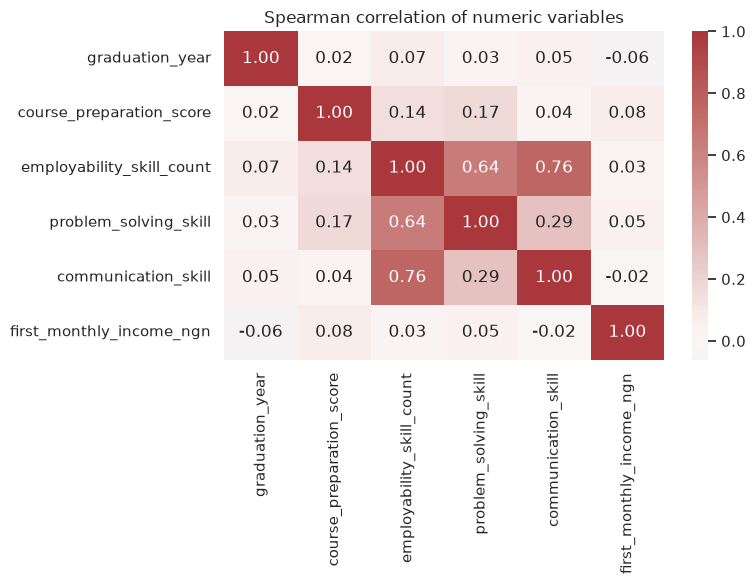

In [4]:
corr = data[NUMERIC_FEATURES + [TARGET]].corr(method="spearman")
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Spearman correlation of numeric variables")
plt.tight_layout()
plt.show()

## Visualization 3: pathways that affect training decisions

Sector medians and employer-valued factors show why program design should include both
curriculum and exposure to work. The comparison informs technology bootcamp curricula,
internship partnerships, and career preparation rather than making promises to individuals.

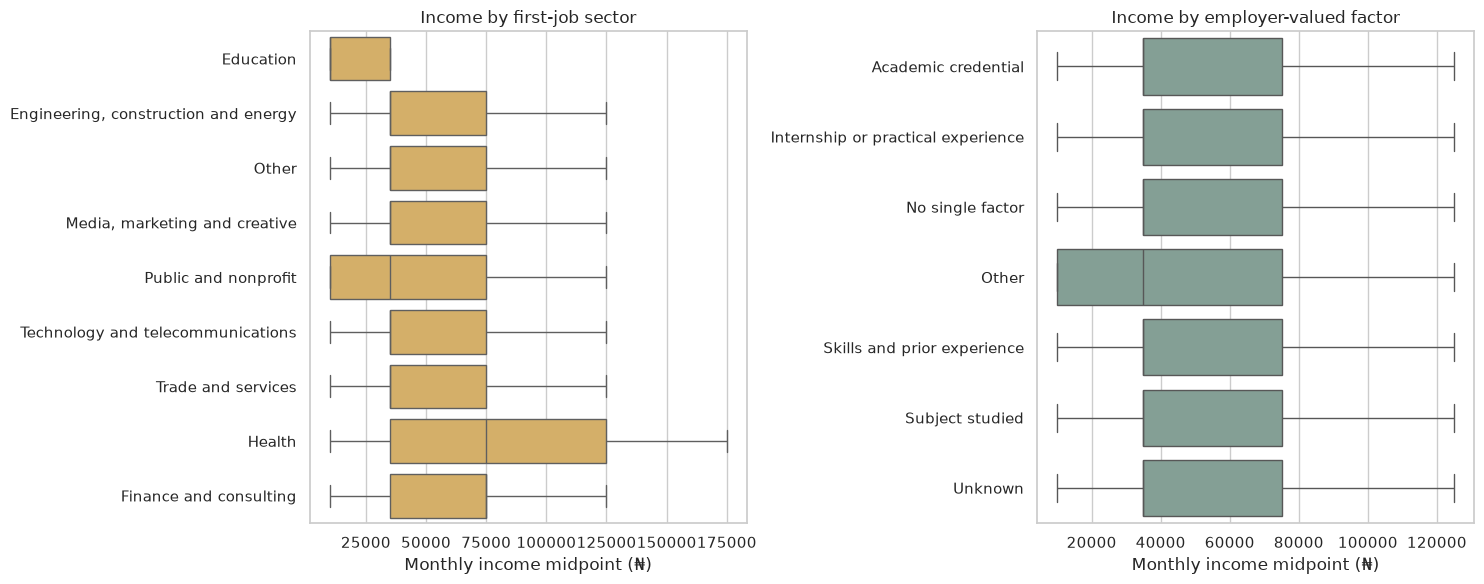

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sector_order = data.groupby("first_job_sector")[TARGET].median().sort_values().index
sns.boxplot(
    data=data, y="first_job_sector", x=TARGET, order=sector_order,
    showfliers=False, ax=axes[0], color="#e6b557"
)
axes[0].set(title="Income by first-job sector", xlabel="Monthly income midpoint (₦)", ylabel="")
factor_order = data.groupby("employer_valued_factor")[TARGET].median().sort_values().index
sns.boxplot(
    data=data, y="employer_valued_factor", x=TARGET, order=factor_order,
    showfliers=False, ax=axes[1], color="#7fa496"
)
axes[1].set(
    title="Income by employer-valued factor",
    xlabel="Monthly income midpoint (₦)",
    ylabel="",
)
plt.tight_layout()
plt.show()

## Four regression implementations

The comparison uses the same stratified 80/20 split:

1. ordinary `LinearRegression`;
2. stochastic-gradient `SGDRegressor`, tuned with five-fold cross-validation;
3. `DecisionTreeRegressor`;
4. ensemble `RandomForestRegressor`.

RMSE in original 2018 naira is the selection loss because large pathway-estimation errors
matter. MAE and R² are reported so a low-looking single metric cannot hide weak fit.

In [6]:
X = data[MODEL_FEATURES]
y = data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

trained_models = {}
metric_rows = []
for name, estimator in model_definitions().items():
    model = tune_sgd(X_train, y_train) if name == "SGDRegressor" else make_pipeline(estimator)
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    trained_models[name] = model
    metric_rows.append({"model": name, **calculate_metrics(y_test, prediction)})

metrics = pd.DataFrame(metric_rows).set_index("model").sort_values("rmse_ngn")
baseline = calculate_metrics(y_test, np.repeat(y_train.median(), len(y_test)))
display(metrics)
display(pd.DataFrame([baseline], index=["Median baseline"]))

,rmse_ngn,mae_ngn,r2
model,,,
LinearRegression,43830.235244,30329.203392,0.132038
SGDRegressor,43900.977364,30378.744834,0.129234
RandomForestRegressor,44474.954153,30638.190573,0.106316
DecisionTreeRegressor,46868.473453,32641.041159,0.007536


,rmse_ngn,mae_ngn,r2
Median baseline,50561.605034,29066.26506,-0.155034


## SGD train and test loss

The target is standardized during optimization so stochastic gradient descent is stable.
The curve is transformed back to naira RMSE for interpretation. The learning-rate schedule,
initial step size, L2 regularization strength, and epochs are tunable hyperparameters.

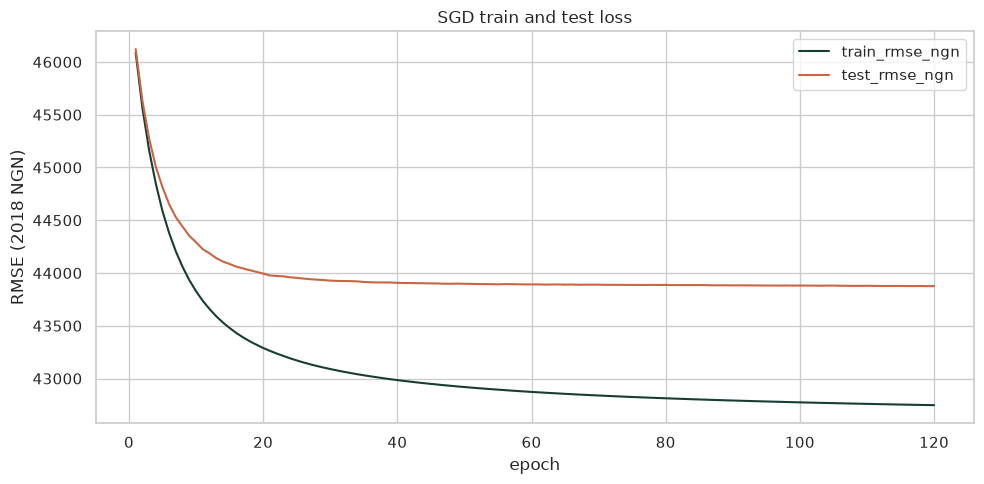

,epoch,train_rmse_ngn,test_rmse_ngn
115,116,42752.226787,43876.597177
116,117,42751.023774,43876.332481
117,118,42749.853477,43876.844110
118,119,42748.697113,43875.481434
119,120,42747.568104,43875.444187


In [7]:
loss_curve = build_sgd_loss_curve(X_train, X_test, y_train, y_test)
loss_curve.plot(
    x="epoch", y=["train_rmse_ngn", "test_rmse_ngn"],
    figsize=(10, 5), color=["#173d34", "#c86545"]
)
plt.ylabel("RMSE (2018 NGN)")
plt.title("SGD train and test loss")
plt.tight_layout()
plt.show()
loss_curve.tail()

## Before and after: fitted linear projection

This is multivariate regression, so a single chart cannot show all dimensions. The right
panel varies employability-skill count from 0–6 while holding other features at representative
values. It shows where the ordinary linear model passes through that one-feature projection.

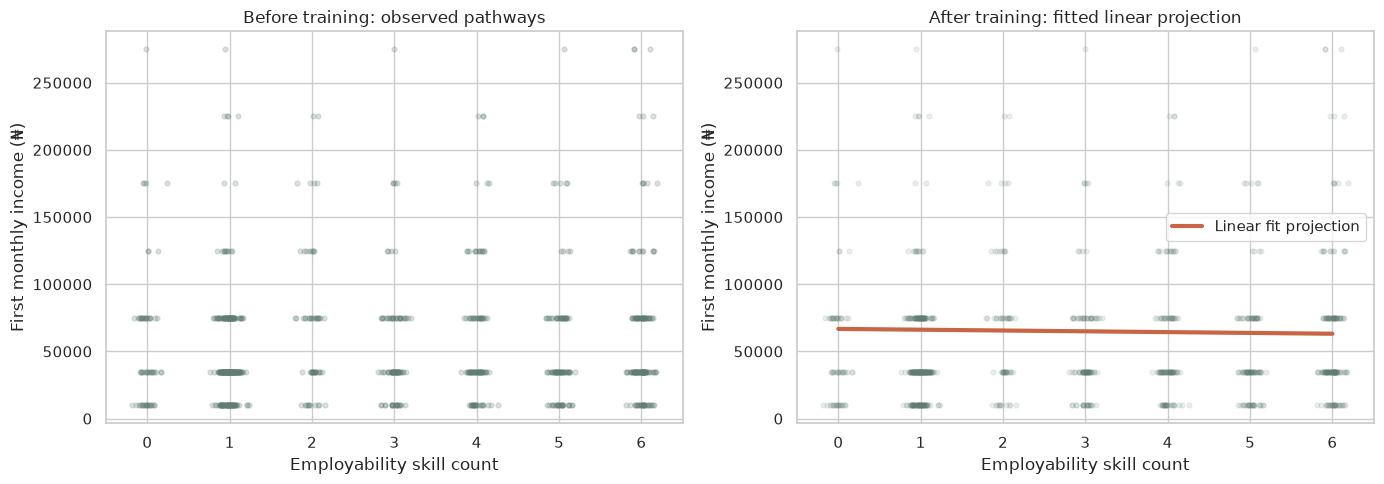

In [8]:
linear = trained_models["LinearRegression"]
sample = data.sample(min(900, len(data)), random_state=RANDOM_STATE).copy()
sample["skill_jitter"] = (
    sample["employability_skill_count"]
    + np.random.default_rng(42).normal(0, .08, len(sample))
)
representative = {}
for column in MODEL_FEATURES:
    representative[column] = (
        data[column].median() if column in NUMERIC_FEATURES else data[column].mode().iat[0]
    )
skill_grid = np.linspace(0, 6, 100)
projection = pd.DataFrame([representative] * len(skill_grid))
projection["employability_skill_count"] = skill_grid
fitted = linear.predict(projection)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(sample["skill_jitter"], sample[TARGET], s=12, alpha=.22, color="#607d75")
axes[0].set(
    title="Before training: observed pathways",
    xlabel="Employability skill count",
    ylabel="First monthly income (₦)",
)
axes[1].scatter(sample["skill_jitter"], sample[TARGET], s=12, alpha=.12, color="#607d75")
axes[1].plot(skill_grid, fitted, color="#c86545", linewidth=3, label="Linear fit projection")
axes[1].legend()
axes[1].set(
    title="After training: fitted linear projection",
    xlabel="Employability skill count",
    ylabel="First monthly income (₦)",
)
plt.tight_layout()
plt.show()

## Save the winner and predict one held-out row

The full winning pipeline is saved, not only the estimator. This preserves imputation,
numeric standardization, category conversion, and the model as one deployable artifact.

In [9]:
best_name = metrics.index[0]
joblib.dump(trained_models[best_name], "models/best_model.joblib")
loss_curve.to_csv("models/sgd_loss_curve.csv", index=False)
print("Saved:", best_name)
print("Selection rule: lowest held-out RMSE in 2018 Nigerian naira")

saved_model = joblib.load("models/best_model.joblib")
one_row = X_test.iloc[[0]]
actual = float(y_test.loc[one_row.index[0]])
predicted = float(saved_model.predict(one_row)[0])
display(one_row)
print(f"Actual band midpoint: ₦{actual:,.0f}")
print(f"Predicted benchmark: ₦{predicted:,.0f}")

Saved: LinearRegression
Selection rule: lowest held-out RMSE in 2018 Nigerian naira


,graduation_year,education_level,course_group,first_job_level,first_job_sector,qualification_requirement,first_job_via_nysc,employer_valued_factor,course_preparation_score,employability_skill_count,problem_solving_skill,communication_skill
9,2016,Bachelor's degree,Social sciences,Clerical and administrative,Technology and telecommunications,Unknown,No,Unknown,2,4,True,True


Actual band midpoint: ₦35,000
Predicted benchmark: ₦64,562


## Interpretation, limitations, and new data

The winning model beats the median RMSE baseline, but R² remains low. That is an important
finding: education and observable skill pathways explain only a limited share of first-income
variation. Loss could be reduced with exact income, portfolio quality, internship duration,
technical assessment scores, location, employer size, and newer multi-country African data.

The result should guide questions for teaching, bootcamps, training, internships, and employer
partnerships. It must not decide who deserves an opportunity. The source is self-selected,
income is midpoint-coded, values are historical 2018 naira, and Nigeria cannot represent the
whole continent.

`POST /retrain` accepts new labelled rows, validates the same schema, compares all four
algorithms again, atomically saves the lowest-RMSE pipeline, and reloads it for prediction.